In [53]:
import numpy as np
import yfinance as yf
import pandas as pd

In [54]:
tickers = [
    "SPY",   # S&P 500 ETF
    "AAPL",  # Apple
    "NVDA",  # Nvidia
    "MSFT",  # Microsoft
    "JPM",   # JPMorgan Chase
    "BAC",   # Bank of America
    "SHEL",  # Shell
    "XOM",   # Exxon Mobil
    "GLD",   # SPDR Gold Shares
    "BZ=F",  # Brent crude oil futures
    "NG=F"   # Natural gas (Henry Hub) futures
]

START_DATE = "2010-01-01"
END_DATE = "2026-09-14"

In [55]:
data = yf.download(
    tickers,
    start=START_DATE,
    end=END_DATE,
    interval="1d",
    auto_adjust=True,
    progress=False
)


In [56]:
data

Price            Close                                                 \
Ticker            AAPL        BAC        BZ=F         GLD         JPM   
Date                                                                    
2010-01-04    6.400959  11.977123   80.120003  109.800003   28.152372   
2010-01-05    6.412028  12.366439   80.589996  109.699997   28.697691   
2010-01-06    6.310034  12.511475   81.889999  111.510002   28.855354   
2010-01-07    6.298370  12.923690   81.510002  110.820000   29.426958   
2010-01-08    6.340246  12.809185   81.370003  111.370003   29.354677   
...                ...        ...         ...         ...         ...   
2026-09-04  319.970001  62.680000   96.279999  406.769989  358.640015   
2026-09-08  316.220001  62.389999   97.919998  399.720001  353.510010   
2026-09-09  315.339996  62.669998  101.209999  403.350006  354.709991   
2026-09-10  326.570007  62.560001  107.629997  396.359985  353.559998   
2026-09-11  332.269989  62.689999  104.610001  398.769989  356.230011   

Price                                                             ...  \
Ticker            MSFT   NG=F        NVDA       SHEL         SPY  ...   
Date                                                              ...   
2010-01-04   22.984232  5.884    0.422817  26.799503   84.368988  ...   
2010-01-05   22.991663  5.637    0.428991  26.829588   84.592293  ...   
2010-01-06   22.850567  6.009    0.431736  26.610382   84.651871  ...   
2010-01-07   22.612921  5.806    0.423275  26.481430   85.009201  ...   
2010-01-08   22.768871  5.749    0.424189  26.442739   85.292084  ...   
...                ...    ...         ...        ...         ...  ...   
2026-09-04  499.700012  2.975  230.102524  92.949997  768.282227  ...   
2026-09-08  493.950012  2.916  225.477692  95.320000  764.062683  ...   
2026-09-09  491.649994  2.822  223.419998  95.599998  760.511536  ...   
2026-09-10  492.440002  2.834  218.360001  95.959999  755.952820  ...   
2026-09-11  495.630005  2.831  218.289993  96.769997  762.396790  ...   

Price            Volume                                               \
Ticker              BAC     BZ=F         GLD         JPM        MSFT   
Date                                                                   
2010-01-04  180845200.0     97.0  16224100.0  35460500.0  38409100.0   
2010-01-05  209521300.0     97.0  14213100.0  41208300.0  49749600.0   
2010-01-06  205257900.0      7.0  24981900.0  27729000.0  58182400.0   
2010-01-07  320868400.0      7.0  13609800.0  44864700.0  50559700.0   
2010-01-08  220104700.0      7.0  15894600.0  33110100.0  51197400.0   
...                 ...      ...         ...         ...         ...   
2026-09-04   26587200.0  35106.0   9813200.0   4873500.0  18101800.0   
2026-09-08   28338000.0  71135.0   8992200.0   5631400.0  18882300.0   
2026-09-09   36015200.0  51567.0   8188400.0   6318200.0  12889600.0   
2026-09-10   29359100.0  72538.0  10202900.0   4184200.0  16038800.0   
2026-09-11   28873700.0  61285.0  10963000.0   5354600.0  14510500.0   

Price                                                                  
Ticker          NG=F         NVDA       SHEL          SPY         XOM  
Date                                                                   
2010-01-04   78858.0  800204000.0  1643003.0  118944600.0  27809100.0  
2010-01-05   99492.0  728648000.0  1718458.0  111579900.0  30174700.0  
2010-01-06  140611.0  649168000.0  3040554.0  116074400.0  35044700.0  
2010-01-07  135113.0  547792000.0  1033089.0  131091100.0  27192100.0  
2010-01-08  101153.0  478168000.0  1438017.0  126402800.0  24891800.0  
...              ...          ...        ...          ...         ...  
2026-09-04  150051.0  135352400.0  6849003.0   34054200.0  16206400.0  
2026-09-08  248447.0  122965600.0  7425065.0   44746100.0  12607700.0  
2026-09-09  178990.0   82955500.0  8384823.0   32812400.0  13124000.0  
2026-09-10  174179.0  105768000.0  6483274.0   42740400.0  16615300.0  
2026-09-1

In [57]:
data = data["Close"].sort_index()

In [58]:
data.tail()

Ticker,AAPL,BAC,BZ=F,GLD,JPM,MSFT,NG=F,NVDA,SHEL,SPY,XOM
Date,,,,,,,,,,,
2026-09-04,319.970001,62.680000,96.279999,406.769989,358.640015,499.700012,2.975,230.102524,92.949997,768.282227,159.470001
2026-09-08,316.220001,62.389999,97.919998,399.720001,353.510010,493.950012,2.916,225.477692,95.320000,764.062683,160.660004
2026-09-09,315.339996,62.669998,101.209999,403.350006,354.709991,491.649994,2.822,223.419998,95.599998,760.511536,164.229996
2026-09-10,326.570007,62.560001,107.629997,396.359985,353.559998,492.440002,2.834,218.360001,95.959999,755.952820,165.229996
2026-09-11,332.269989,62.689999,104.610001,398.769989,356.230011,495.630005,2.831,218.289993,96.769997,762.396790,165.990005


In [59]:
data

Ticker,AAPL,BAC,BZ=F,GLD,JPM,MSFT,NG=F,NVDA,SHEL,SPY,XOM
Date,,,,,,,,,,,
2010-01-04,6.400959,11.977123,80.120003,109.800003,28.152372,22.984232,5.884,0.422817,26.799503,84.368988,37.136810
2010-01-05,6.412028,12.366439,80.589996,109.699997,28.697691,22.991663,5.637,0.428991,26.829588,84.592293,37.281815
2010-01-06,6.310034,12.511475,81.889999,111.510002,28.855354,22.850567,6.009,0.431736,26.610382,84.651871,37.604042
2010-01-07,6.298370,12.923690,81.510002,110.820000,29.426958,22.612921,5.806,0.423275,26.481430,85.009201,37.485897
2010-01-08,6.340246,12.809185,81.370003,111.370003,29.354677,22.768871,5.749,0.424189,26.442739,85.292084,37.335506
...,...,...,...,...,...,...,...,...,...,...,...
2026-09-04,319.970001,62.680000,96.279999,406.769989,358.640015,499.700012,2.975,230.102524,92.949997,768.282227,159.470001
2026-09-08,316.220001,62.389999,97.919998,399.720001,353.510010,493.950012,2.916,225.477692,95.320000,764.062683,160.660004
2026-09-09,315.339996,62.669998,101.209999,403.350006,354.709991,491.649994,2.822,223.419998,95.599998,760.511536,164.229996


In [60]:
# date orrdre croissant
data.tail(10)

Ticker,AAPL,BAC,BZ=F,GLD,JPM,MSFT,NG=F,NVDA,SHEL,SPY,XOM
Date,,,,,,,,,,,
2026-08-28,319.700012,62.003654,89.309998,408.890015,357.619995,513.530029,2.888,217.306839,90.910004,767.444275,156.710007
2026-08-31,316.850006,61.625580,90.489998,408.420013,356.019989,507.290009,2.935,220.533234,91.449997,765.149963,160.949997
2026-09-01,325.130005,61.675331,94.650002,396.750000,354.950012,501.019989,2.904,217.196976,93.510002,759.893066,164.550003
2026-09-02,324.959991,62.282230,95.629997,402.779999,356.220001,496.820007,2.956,224.159180,92.800003,763.264648,164.149994
2026-09-03,328.209991,62.719997,95.519997,410.220001,362.059998,510.119995,2.913,228.194656,92.330002,771.254822,162.210007
2026-09-04,319.970001,62.680000,96.279999,406.769989,358.640015,499.700012,2.975,230.102524,92.949997,768.282227,159.470001
2026-09-08,316.220001,62.389999,97.919998,399.720001,353.510010,493.950012,2.916,225.477692,95.320000,764.062683,160.660004
2026-09-09,315.339996,62.669998,101.209999,403.350006,354.709991,491.649994,2.822,223.419998,95.599998,760.511536,164.229996
2026-09-10,326.570007,62.560001,107.629997,396.359985,353.559998,492.440002,2.834,218.360001,95.959999,755.952820,165.229996


In [61]:
data.rename(columns={
    
    "SPY": "S&P 500",
    "AAPL": "Apple",
    "NVDA": "Nvidia",
    "MSFT": "Microsoft",
    "JPM": "JPMorgan",
    "BAC": "Bank of America",
    "SHEL": "Shell",
    "XOM": "Exxon Mobil",
    "GLD": "Gold",
    "BZ=F": "Oil",
    "NG=F": "Gas"
    
},inplace = True)

In [62]:
data.head(10)

Ticker,Apple,Bank of America,Oil,Gold,JPMorgan,Microsoft,Gas,Nvidia,Shell,S&P 500,Exxon Mobil
Date,,,,,,,,,,,
2010-01-04,6.400959,11.977123,80.120003,109.800003,28.152372,22.984232,5.884,0.422817,26.799503,84.368988,37.136810
2010-01-05,6.412028,12.366439,80.589996,109.699997,28.697691,22.991663,5.637,0.428991,26.829588,84.592293,37.281815
2010-01-06,6.310034,12.511475,81.889999,111.510002,28.855354,22.850567,6.009,0.431736,26.610382,84.651871,37.604042
2010-01-07,6.298370,12.923690,81.510002,110.820000,29.426958,22.612921,5.806,0.423275,26.481430,85.009201,37.485897
2010-01-08,6.340246,12.809185,81.370003,111.370003,29.354677,22.768871,5.749,0.424189,26.442739,85.292084,37.335506
2010-01-11,6.284312,12.923690,80.970001,112.849998,29.256132,22.479261,5.454,0.418244,26.855371,85.411232,37.754406
2010-01-12,6.212827,12.488573,79.300003,110.489998,28.572866,22.330725,5.591,0.404066,26.249319,84.614655,37.566444
2010-01-13,6.300462,12.687052,78.309998,111.540001,29.072182,22.538664,5.733,0.409554,26.266518,85.329315,37.416069
2010-01-14,6.263973,12.839720,77.820000,112.029999,29.361248,22.991663,5.588,0.403151,26.202051,85.560104,37.421455


In [63]:
# savoir le nombre de NaN
data.isna().sum()

Ticker
Apple               3
Bank of America     3
Oil                34
Gold                3
JPMorgan            3
Microsoft           3
Gas                 2
Nvidia              3
Shell               3
S&P 500             3
Exxon Mobil         3
dtype: int64

In [64]:
data.dropna(inplace=True)
data.isna().sum()

Ticker
Apple              0
Bank of America    0
Oil                0
Gold               0
JPMorgan           0
Microsoft          0
Gas                0
Nvidia             0
Shell              0
S&P 500            0
Exxon Mobil        0
dtype: int64

In [65]:
data

Ticker,Apple,Bank of America,Oil,Gold,JPMorgan,Microsoft,Gas,Nvidia,Shell,S&P 500,Exxon Mobil
Date,,,,,,,,,,,
2010-01-04,6.400959,11.977123,80.120003,109.800003,28.152372,22.984232,5.884,0.422817,26.799503,84.368988,37.136810
2010-01-05,6.412028,12.366439,80.589996,109.699997,28.697691,22.991663,5.637,0.428991,26.829588,84.592293,37.281815
2010-01-06,6.310034,12.511475,81.889999,111.510002,28.855354,22.850567,6.009,0.431736,26.610382,84.651871,37.604042
2010-01-07,6.298370,12.923690,81.510002,110.820000,29.426958,22.612921,5.806,0.423275,26.481430,85.009201,37.485897
2010-01-08,6.340246,12.809185,81.370003,111.370003,29.354677,22.768871,5.749,0.424189,26.442739,85.292084,37.335506
...,...,...,...,...,...,...,...,...,...,...,...
2026-09-04,319.970001,62.680000,96.279999,406.769989,358.640015,499.700012,2.975,230.102524,92.949997,768.282227,159.470001
2026-09-08,316.220001,62.389999,97.919998,399.720001,353.510010,493.950012,2.916,225.477692,95.320000,764.062683,160.660004
2026-09-09,315.339996,62.669998,101.209999,403.350006,354.709991,491.649994,2.822,223.419998,95.599998,760.511536,164.229996


In [66]:
data.columns

Index(['Apple', 'Bank of America', 'Oil', 'Gold', 'JPMorgan', 'Microsoft',
       'Gas', 'Nvidia', 'Shell', 'S&P 500', 'Exxon Mobil'],
      dtype='object', name='Ticker')

In [67]:
column = ["S&P 500", "Nvidia", "Apple", "Microsoft", "JPMorgan", "Bank of America", "Exxon Mobil", "Shell", "Gold", "Oil", "Gas" ]
data = data[column]

In [68]:
data

Ticker,S&P 500,Nvidia,Apple,Microsoft,JPMorgan,Bank of America,Exxon Mobil,Shell,Gold,Oil,Gas
Date,,,,,,,,,,,
2010-01-04,84.368988,0.422817,6.400959,22.984232,28.152372,11.977123,37.136810,26.799503,109.800003,80.120003,5.884
2010-01-05,84.592293,0.428991,6.412028,22.991663,28.697691,12.366439,37.281815,26.829588,109.699997,80.589996,5.637
2010-01-06,84.651871,0.431736,6.310034,22.850567,28.855354,12.511475,37.604042,26.610382,111.510002,81.889999,6.009
2010-01-07,85.009201,0.423275,6.298370,22.612921,29.426958,12.923690,37.485897,26.481430,110.820000,81.510002,5.806
2010-01-08,85.292084,0.424189,6.340246,22.768871,29.354677,12.809185,37.335506,26.442739,111.370003,81.370003,5.749
...,...,...,...,...,...,...,...,...,...,...,...
2026-09-04,768.282227,230.102524,319.970001,499.700012,358.640015,62.680000,159.470001,92.949997,406.769989,96.279999,2.975
2026-09-08,764.062683,225.477692,316.220001,493.950012,353.510010,62.389999,160.660004,95.320000,399.720001,97.919998,2.916
2026-09-09,760.511536,223.419998,315.339996,491.649994,354.709991,62.669998,164.229996,95.599998,403.350006,101.209999,2.822


In [69]:
data.iloc[-1]

Ticker
S&P 500            762.396790
Nvidia             218.289993
Apple              332.269989
Microsoft          495.630005
JPMorgan           356.230011
Bank of America     62.689999
Exxon Mobil        165.990005
Shell               96.769997
Gold               398.769989
Oil                104.610001
Gas                  2.831000
Name: 2026-09-11 00:00:00, dtype: float64

In [70]:
# dataframe avec les rendemtns
returns = data.pct_change().dropna()
returns

Ticker,S&P 500,Nvidia,Apple,Microsoft,JPMorgan,Bank of America,Exxon Mobil,Shell,Gold,Oil,Gas
Date,,,,,,,,,,,
2010-01-05,0.002647,0.014603,0.001729,0.000323,0.019370,0.032505,0.003905,0.001123,-0.000911,0.005866,-0.041978
2010-01-06,0.000704,0.006397,-0.015907,-0.006137,0.005494,0.011728,0.008643,-0.008170,0.016500,0.016131,0.065993
2010-01-07,0.004221,-0.019598,-0.001848,-0.010400,0.019809,0.032947,-0.003142,-0.004846,-0.006188,-0.004640,-0.033783
2010-01-08,0.003328,0.002162,0.006649,0.006897,-0.002456,-0.008860,-0.004012,-0.001461,0.004963,-0.001718,-0.009817
2010-01-11,0.001397,-0.014017,-0.008822,-0.012720,-0.003357,0.008939,0.011220,0.015605,0.013289,-0.004916,-0.051313
...,...,...,...,...,...,...,...,...,...,...,...
2026-09-04,-0.003854,0.008361,-0.025106,-0.020427,-0.009446,-0.000638,-0.016892,0.006715,-0.008410,0.007956,0.021284
2026-09-08,-0.005492,-0.020099,-0.011720,-0.011507,-0.014304,-0.004627,0.007462,0.025498,-0.017332,0.017034,-0.019832
2026-09-09,-0.004648,-0.009126,-0.002783,-0.004656,0.003394,0.004488,0.022221,0.002937,0.009081,0.033599,-0.032236


In [71]:
# on ne garde que les jours ou rendement S&P inf à 3%
crash_days = returns.loc[returns["S&P 500"]<=-0.03]
crash_days

Ticker,S&P 500,Nvidia,Apple,Microsoft,JPMorgan,Bank of America,Exxon Mobil,Shell,Gold,Oil,Gas
Date,,,,,,,,,,,
2010-02-04,-0.030866,-0.058057,-0.036039,-0.027593,-0.048151,-0.050225,-0.028228,-0.040719,-0.039834,-0.049921,-0.000554
2010-05-06,-0.033213,-0.020690,-0.038048,-0.029145,-0.042693,-0.071307,-0.034457,-0.034560,0.029542,-0.033652,-0.015535
2010-05-20,-0.037760,-0.023511,-0.042603,-0.040014,-0.039360,-0.061925,-0.033947,-0.017350,-0.006774,-0.025105,-0.012506
2010-06-04,-0.035137,-0.047244,-0.027212,-0.039836,-0.037851,-0.029096,-0.032976,-0.042176,0.010427,-0.044026,0.022814
2010-06-29,-0.030875,-0.055856,-0.045211,-0.041135,-0.038402,-0.043963,-0.020181,-0.031593,0.001487,-0.027710,-0.035828
2011-08-04,-0.046841,-0.095206,-0.038719,-0.036404,-0.049624,-0.074424,-0.049923,-0.070523,-0.005264,-0.052813,-0.036430
2011-08-08,-0.065123,-0.078764,-0.054627,-0.046729,-0.094149,-0.203182,-0.061881,-0.068168,0.033199,-0.051477,-0.001522
2011-08-10,-0.044178,-0.045630,-0.027593,-0.053948,-0.055770,-0.109211,-0.044120,-0.040357,0.035407,0.040070,0.002253
2011-08-18,-0.043119,-0.067915,-0.037825,-0.022970,-0.037736,-0.060322,-0.043419,-0.036077,0.018920,-0.032640,-0.010425


In [72]:
# On affiche le nombre de jours de crash, la plus petite / grande date, top 5 rendements les plus faibles

print(len(crash_days))
print(crash_days.index.min().date())
print(crash_days.index.max().date())
crash_days["S&P 500"].nsmallest(5)

46
2010-02-04
2025-04-10


Date
2020-03-16   -0.109424
2020-03-12   -0.095677
2020-03-09   -0.078095
2011-08-08   -0.065123
2025-04-04   -0.058543
Name: S&P 500, dtype: float64

In [73]:
crash_days

Ticker,S&P 500,Nvidia,Apple,Microsoft,JPMorgan,Bank of America,Exxon Mobil,Shell,Gold,Oil,Gas
Date,,,,,,,,,,,
2010-02-04,-0.030866,-0.058057,-0.036039,-0.027593,-0.048151,-0.050225,-0.028228,-0.040719,-0.039834,-0.049921,-0.000554
2010-05-06,-0.033213,-0.020690,-0.038048,-0.029145,-0.042693,-0.071307,-0.034457,-0.034560,0.029542,-0.033652,-0.015535
2010-05-20,-0.037760,-0.023511,-0.042603,-0.040014,-0.039360,-0.061925,-0.033947,-0.017350,-0.006774,-0.025105,-0.012506
2010-06-04,-0.035137,-0.047244,-0.027212,-0.039836,-0.037851,-0.029096,-0.032976,-0.042176,0.010427,-0.044026,0.022814
2010-06-29,-0.030875,-0.055856,-0.045211,-0.041135,-0.038402,-0.043963,-0.020181,-0.031593,0.001487,-0.027710,-0.035828
2011-08-04,-0.046841,-0.095206,-0.038719,-0.036404,-0.049624,-0.074424,-0.049923,-0.070523,-0.005264,-0.052813,-0.036430
2011-08-08,-0.065123,-0.078764,-0.054627,-0.046729,-0.094149,-0.203182,-0.061881,-0.068168,0.033199,-0.051477,-0.001522
2011-08-10,-0.044178,-0.045630,-0.027593,-0.053948,-0.055770,-0.109211,-0.044120,-0.040357,0.035407,0.040070,0.002253
2011-08-18,-0.043119,-0.067915,-0.037825,-0.022970,-0.037736,-0.060322,-0.043419,-0.036077,0.018920,-0.032640,-0.010425


In [74]:
# on calcule ensuite coefficients régression

import statsmodels.api as sm

results = []

benchmark = "S&P 500"
for asset in crash_days.columns:

    if asset == benchmark:
        continue

    y = crash_days[asset]
    X = crash_days[benchmark]

    X = sm.add_constant(X)

    model = sm.OLS(y,X).fit()

    results.append(
    {
        "Asset": asset,
        "alpha": model.params["const"],
        "crash_beta":model.params[benchmark],
        "std_error": model.bse[benchmark],
        "t_stat":model.tvalues[benchmark],
        "p_value":model.pvalues[benchmark],
        "r_squared":model.rsquared,
        "n_crash_days":int(model.nobs),
    }
    )




In [75]:
results

[{'Asset': 'Nvidia',
  'alpha': np.float64(-0.022377689204453856),
  'crash_beta': np.float64(1.0586404921972736),
  'std_error': np.float64(0.1951916622326899),
  't_stat': np.float64(5.423594840517613),
  'p_value': np.float64(2.3541346084167e-06),
  'r_squared': np.float64(0.40067054881125674),
  'n_crash_days': 46},
 {'Asset': 'Apple',
  'alpha': np.float64(-0.006667225883774708),
  'crash_beta': np.float64(0.9516433963829345),
  'std_error': np.float64(0.13907405137687978),
  't_stat': np.float64(6.842709958912863),
  'p_value': np.float64(1.9445659673986463e-08),
  'r_squared': np.float64(0.5155395083849228),
  'n_crash_days': 46},
 {'Asset': 'Microsoft',
  'alpha': np.float64(-0.004075812041936073),
  'crash_beta': np.float64(0.9492939859625362),
  'std_error': np.float64(0.1292048739312416),
  't_stat': np.float64(7.347199506326037),
  'p_value': np.float64(3.553087393390386e-09),
  'r_squared': np.float64(0.5509349051874903),
  'n_crash_days': 46},
 {'Asset': 'JPMorgan',
  'al

In [76]:
crash_betas = pd.DataFrame(results)
crash_betas

,Asset,alpha,crash_beta,std_error,t_stat,p_value,r_squared,n_crash_days
0,Nvidia,-0.022378,1.058640,0.195192,5.423595,2.354135e-06,0.400671,46
1,Apple,-0.006667,0.951643,0.139074,6.842710,1.944566e-08,0.515540,46
2,Microsoft,-0.004076,0.949294,0.129205,7.347200,3.553087e-09,0.550935,46
3,JPMorgan,0.014479,1.465011,0.160352,9.136216,1.004124e-11,0.654822,46
4,Bank of America,0.014415,1.696672,0.241266,7.032379,1.024869e-08,0.529182,46
5,Exxon Mobil,0.011551,1.271886,0.167942,7.573384,1.665956e-09,0.565887,46
6,Shell,0.039655,1.982111,0.262100,7.562430,1.728057e-09,0.565176,46
7,Gold,0.008246,0.201450,0.166082,1.212950,2.316210e-01,0.032356,46
8,Oil,0.019846,1.385903,0.481815,2.876424,6.180050e-03,0.158278,46
9,Gas,-0.015001,0.002463,0.300445,0.008198,9.934964e-01,0.000002,46


In [77]:
#Defining portfolio weight

weight_Nvidia = 0.1
weight_Apple = 0.1
weight_Microsoft = 0.1 
weight_JPMorgan = 0.1
weight_Bank_of_America = 0.1
weight_Exxon_Mobil = 0.1
weight_Shell = 0.1
weight_Gold = 0.1
weight_Oil = 0.1 
weight_Gas = 0.1

s = weight_Nvidia + weight_Apple + weight_Microsoft + weight_JPMorgan + weight_Bank_of_America  + weight_Exxon_Mobil + weight_Shell + weight_Gold + weight_Oil + weight_Gas 
print(s)

0.9999999999999999


In [78]:
list(crash_betas["Asset"])

['Nvidia',
 'Apple',
 'Microsoft',
 'JPMorgan',
 'Bank of America',
 'Exxon Mobil',
 'Shell',
 'Gold',
 'Oil',
 'Gas']

In [79]:
dico = {
    "Asset":list(crash_betas["Asset"]),
    "Weight":[weight_Nvidia,
            weight_Apple, 
                weight_Microsoft,
                weight_JPMorgan,
                weight_Bank_of_America,
                weight_Exxon_Mobil, 
                weight_Shell,
                weight_Gold,
                weight_Oil,
                weight_Gas ]
}

In [80]:
weight = pd.DataFrame(dico)
weight

,Asset,Weight
0,Nvidia,0.1
1,Apple,0.1
2,Microsoft,0.1
3,JPMorgan,0.1
4,Bank of America,0.1
5,Exxon Mobil,0.1
6,Shell,0.1
7,Gold,0.1
8,Oil,0.1
9,Gas,0.1


In [81]:
portfolio = crash_betas[["Asset","crash_beta"]]
portfolio

,Asset,crash_beta
0,Nvidia,1.058640
1,Apple,0.951643
2,Microsoft,0.949294
3,JPMorgan,1.465011
4,Bank of America,1.696672
5,Exxon Mobil,1.271886
6,Shell,1.982111
7,Gold,0.201450
8,Oil,1.385903
9,Gas,0.002463


In [82]:
portfolio = pd.merge(portfolio,weight,left_on="Asset",right_on = "Asset")
portfolio

,Asset,crash_beta,Weight
0,Nvidia,1.058640,0.1
1,Apple,0.951643,0.1
2,Microsoft,0.949294,0.1
3,JPMorgan,1.465011,0.1
4,Bank of America,1.696672,0.1
5,Exxon Mobil,1.271886,0.1
6,Shell,1.982111,0.1
7,Gold,0.201450,0.1
8,Oil,1.385903,0.1
9,Gas,0.002463,0.1


In [83]:
data.iloc[-1] # une series

Ticker
S&P 500            762.396790
Nvidia             218.289993
Apple              332.269989
Microsoft          495.630005
JPMorgan           356.230011
Bank of America     62.689999
Exxon Mobil        165.990005
Shell               96.769997
Gold               398.769989
Oil                104.610001
Gas                  2.831000
Name: 2026-09-11 00:00:00, dtype: float64

In [84]:
spot_price = data.tail(1) # un dataframe
spot_price

Ticker,S&P 500,Nvidia,Apple,Microsoft,JPMorgan,Bank of America,Exxon Mobil,Shell,Gold,Oil,Gas
Date,,,,,,,,,,,
2026-09-11,762.39679,218.289993,332.269989,495.630005,356.230011,62.689999,165.990005,96.769997,398.769989,104.610001,2.831


In [85]:
spot_price = data.tail(1).transpose()  # un dataframe
spot_price

Date,2026-09-11
Ticker,
S&P 500,762.396790
Nvidia,218.289993
Apple,332.269989
Microsoft,495.630005
JPMorgan,356.230011
Bank of America,62.689999
Exxon Mobil,165.990005
Shell,96.769997
Gold,398.769989


In [86]:
portfolio = pd.merge(portfolio,spot_price,left_on="Asset",right_on="Ticker")
portfolio

,Asset,crash_beta,Weight,2026-09-11 00:00:00
0,Nvidia,1.058640,0.1,218.289993
1,Apple,0.951643,0.1,332.269989
2,Microsoft,0.949294,0.1,495.630005
3,JPMorgan,1.465011,0.1,356.230011
4,Bank of America,1.696672,0.1,62.689999
5,Exxon Mobil,1.271886,0.1,165.990005
6,Shell,1.982111,0.1,96.769997
7,Gold,0.201450,0.1,398.769989
8,Oil,1.385903,0.1,104.610001
9,Gas,0.002463,0.1,2.831000


In [87]:
portfolio.columns
L=list(portfolio.columns)
L

['Asset', 'crash_beta', 'Weight', Timestamp('2026-09-11 00:00:00')]

In [88]:
Initial_capital = 1_000_000 
#portfolio["Position Value $"] = Initial_capital * portfolio["Weight"] * portfolio[L[-1]]
portfolio["Position Value $"] = Initial_capital * portfolio["Weight"] 
portfolio
print(sum(portfolio["Position Value $"]))
portfolio

1000000.0


,Asset,crash_beta,Weight,2026-09-11 00:00:00,Position Value $
0,Nvidia,1.058640,0.1,218.289993,100000.0
1,Apple,0.951643,0.1,332.269989,100000.0
2,Microsoft,0.949294,0.1,495.630005,100000.0
3,JPMorgan,1.465011,0.1,356.230011,100000.0
4,Bank of America,1.696672,0.1,62.689999,100000.0
5,Exxon Mobil,1.271886,0.1,165.990005,100000.0
6,Shell,1.982111,0.1,96.769997,100000.0
7,Gold,0.201450,0.1,398.769989,100000.0
8,Oil,1.385903,0.1,104.610001,100000.0
9,Gas,0.002463,0.1,2.831000,100000.0


In [89]:
portfolio["Asset Volume"] = portfolio["Position Value $"]/portfolio[L[-1]]
portfolio

,Asset,crash_beta,Weight,2026-09-11 00:00:00,Position Value $,Asset Volume
0,Nvidia,1.058640,0.1,218.289993,100000.0,458.106203
1,Apple,0.951643,0.1,332.269989,100000.0,300.960073
2,Microsoft,0.949294,0.1,495.630005,100000.0,201.763410
3,JPMorgan,1.465011,0.1,356.230011,100000.0,280.717505
4,Bank of America,1.696672,0.1,62.689999,100000.0,1595.150777
5,Exxon Mobil,1.271886,0.1,165.990005,100000.0,602.445911
6,Shell,1.982111,0.1,96.769997,100000.0,1033.378149
7,Gold,0.201450,0.1,398.769989,100000.0,250.771128
8,Oil,1.385903,0.1,104.610001,100000.0,955.931550
9,Gas,0.002463,0.1,2.831000,100000.0,35323.206229


In [90]:
portfolio.rename(columns={L[-1]:"Spot Price $"},inplace=True)
portfolio

,Asset,crash_beta,Weight,Spot Price $,Position Value $,Asset Volume
0,Nvidia,1.058640,0.1,218.289993,100000.0,458.106203
1,Apple,0.951643,0.1,332.269989,100000.0,300.960073
2,Microsoft,0.949294,0.1,495.630005,100000.0,201.763410
3,JPMorgan,1.465011,0.1,356.230011,100000.0,280.717505
4,Bank of America,1.696672,0.1,62.689999,100000.0,1595.150777
5,Exxon Mobil,1.271886,0.1,165.990005,100000.0,602.445911
6,Shell,1.982111,0.1,96.769997,100000.0,1033.378149
7,Gold,0.201450,0.1,398.769989,100000.0,250.771128
8,Oil,1.385903,0.1,104.610001,100000.0,955.931550
9,Gas,0.002463,0.1,2.831000,100000.0,35323.206229


In [91]:
Shock = [-0.05,-0.1,-0.2,-0.3,-0.4]

dico = {
    "S&P500 Shock":Shock,   
}

stress_results = pd.DataFrame(dico)
stress_results


,S&P500 Shock
0,-0.05
1,-0.10
2,-0.20
3,-0.30
4,-0.40


In [92]:
for _, row in portfolio.iterrows():

    asset = row["Asset"]
    beta = row["crash_beta"]

    stressed_return = beta * stress_results["S&P500 Shock"]

    pnl = row["Position Value $"] * stressed_return

    stress_results[f"{asset} Stressed Return"] = stressed_return
    stress_results[f"{asset} PnL"] = pnl


stress_results

,S&P500 Shock,Nvidia Stressed Return,Nvidia PnL,Apple Stressed Return,Apple PnL,Microsoft Stressed Return,Microsoft PnL,JPMorgan Stressed Return,JPMorgan PnL,Bank of America Stressed Return,...,Exxon Mobil Stressed Return,Exxon Mobil PnL,Shell Stressed Return,Shell PnL,Gold Stressed Return,Gold PnL,Oil Stressed Return,Oil PnL,Gas Stressed Return,Gas PnL
0,-0.05,-0.052932,-5293.202461,-0.047582,-4758.216982,-0.047465,-4746.469930,-0.073251,-7325.055654,-0.084834,...,-0.063594,-6359.432370,-0.099106,-9910.552889,-0.010072,-1007.247631,-0.069295,-6929.514351,-0.000123,-12.314656
1,-0.10,-0.105864,-10586.404922,-0.095164,-9516.433964,-0.094929,-9492.939860,-0.146501,-14650.111308,-0.169667,...,-0.127189,-12718.864740,-0.198211,-19821.105779,-0.020145,-2014.495263,-0.138590,-13859.028702,-0.000246,-24.629311
2,-0.20,-0.211728,-21172.809844,-0.190329,-19032.867928,-0.189859,-18985.879719,-0.293002,-29300.222616,-0.339334,...,-0.254377,-25437.729480,-0.396422,-39642.211558,-0.040290,-4028.990526,-0.277181,-27718.057404,-0.000493,-49.258623
3,-0.30,-0.317592,-31759.214766,-0.285493,-28549.301891,-0.284788,-28478.819579,-0.439503,-43950.333924,-0.509002,...,-0.381566,-38156.594219,-0.594633,-59463.317336,-0.060435,-6043.485789,-0.415771,-41577.086107,-0.000739,-73.887934
4,-0.40,-0.423456,-42345.619688,-0.380657,-38065.735855,-0.379718,-37971.759439,-0.586004,-58600.445232,-0.678669,...,-0.508755,-50875.458959,-0.792844,-79284.423115,-0.080580,-8057.981052,-0.554361,-55436.114809,-0.000985,-98.517245


In [93]:
L=[]
for name in stress_results.columns:
    if "PnL" in name:
        L.append(name)
print(L)

['Nvidia PnL', 'Apple PnL', 'Microsoft PnL', 'JPMorgan PnL', 'Bank of America PnL', 'Exxon Mobil PnL', 'Shell PnL', 'Gold PnL', 'Oil PnL', 'Gas PnL']


In [94]:
stress_results["Portfolio P&L $"] = stress_results[L].sum(axis=1) # somme sur chaque ligne
stress_results

,S&P500 Shock,Nvidia Stressed Return,Nvidia PnL,Apple Stressed Return,Apple PnL,Microsoft Stressed Return,Microsoft PnL,JPMorgan Stressed Return,JPMorgan PnL,Bank of America Stressed Return,...,Exxon Mobil PnL,Shell Stressed Return,Shell PnL,Gold Stressed Return,Gold PnL,Oil Stressed Return,Oil PnL,Gas Stressed Return,Gas PnL,Portfolio P&L $
0,-0.05,-0.052932,-5293.202461,-0.047582,-4758.216982,-0.047465,-4746.469930,-0.073251,-7325.055654,-0.084834,...,-6359.432370,-0.099106,-9910.552889,-0.010072,-1007.247631,-0.069295,-6929.514351,-0.000123,-12.314656,-54825.365738
1,-0.10,-0.105864,-10586.404922,-0.095164,-9516.433964,-0.094929,-9492.939860,-0.146501,-14650.111308,-0.169667,...,-12718.864740,-0.198211,-19821.105779,-0.020145,-2014.495263,-0.138590,-13859.028702,-0.000246,-24.629311,-109650.731476
2,-0.20,-0.211728,-21172.809844,-0.190329,-19032.867928,-0.189859,-18985.879719,-0.293002,-29300.222616,-0.339334,...,-25437.729480,-0.396422,-39642.211558,-0.040290,-4028.990526,-0.277181,-27718.057404,-0.000493,-49.258623,-219301.462952
3,-0.30,-0.317592,-31759.214766,-0.285493,-28549.301891,-0.284788,-28478.819579,-0.439503,-43950.333924,-0.509002,...,-38156.594219,-0.594633,-59463.317336,-0.060435,-6043.485789,-0.415771,-41577.086107,-0.000739,-73.887934,-328952.194429
4,-0.40,-0.423456,-42345.619688,-0.380657,-38065.735855,-0.379718,-37971.759439,-0.586004,-58600.445232,-0.678669,...,-50875.458959,-0.792844,-79284.423115,-0.080580,-8057.981052,-0.554361,-55436.114809,-0.000985,-98.517245,-438602.925905


In [95]:
stress_results["Portfolio Return"] = stress_results["Portfolio P&L $"]/Initial_capital
stress_results
stress_results.round(4)

,S&P500 Shock,Nvidia Stressed Return,Nvidia PnL,Apple Stressed Return,Apple PnL,Microsoft Stressed Return,Microsoft PnL,JPMorgan Stressed Return,JPMorgan PnL,Bank of America Stressed Return,...,Shell Stressed Return,Shell PnL,Gold Stressed Return,Gold PnL,Oil Stressed Return,Oil PnL,Gas Stressed Return,Gas PnL,Portfolio P&L $,Portfolio Return
0,-0.05,-0.0529,-5293.2025,-0.0476,-4758.2170,-0.0475,-4746.4699,-0.0733,-7325.0557,-0.0848,...,-0.0991,-9910.5529,-0.0101,-1007.2476,-0.0693,-6929.5144,-0.0001,-12.3147,-54825.3657,-0.0548
1,-0.10,-0.1059,-10586.4049,-0.0952,-9516.4340,-0.0949,-9492.9399,-0.1465,-14650.1113,-0.1697,...,-0.1982,-19821.1058,-0.0201,-2014.4953,-0.1386,-13859.0287,-0.0002,-24.6293,-109650.7315,-0.1097
2,-0.20,-0.2117,-21172.8098,-0.1903,-19032.8679,-0.1899,-18985.8797,-0.2930,-29300.2226,-0.3393,...,-0.3964,-39642.2116,-0.0403,-4028.9905,-0.2772,-27718.0574,-0.0005,-49.2586,-219301.4630,-0.2193
3,-0.30,-0.3176,-31759.2148,-0.2855,-28549.3019,-0.2848,-28478.8196,-0.4395,-43950.3339,-0.5090,...,-0.5946,-59463.3173,-0.0604,-6043.4858,-0.4158,-41577.0861,-0.0007,-73.8879,-328952.1944,-0.3290
4,-0.40,-0.4235,-42345.6197,-0.3807,-38065.7359,-0.3797,-37971.7594,-0.5860,-58600.4452,-0.6787,...,-0.7928,-79284.4231,-0.0806,-8057.9811,-0.5544,-55436.1148,-0.0010,-98.5172,-438602.9259,-0.4386


In [96]:
summary = stress_results[["S&P500 Shock","Portfolio P&L $","Portfolio Return"]]

summary["S&P500 Shock"] = (summary["S&P500 Shock"].map("{:.0%}".format))
summary["Portfolio P&L $"] = (summary["Portfolio P&L $"].map("{:,.0f} $".format))
summary["Portfolio Return"] = (summary["Portfolio Return"].map("{:.2%}".format))
summary

C:\Users\antoi\AppData\Local\Temp\ipykernel_19088\4213438382.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  summary["S&P500 Shock"] = (summary["S&P500 Shock"].map("{:.0%}".format))
C:\Users\antoi\AppData\Local\Temp\ipykernel_19088\4213438382.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  summary["Portfolio P&L $"] = (summary["Portfolio P&L $"].map("{:,.0f} $".format))
C:\Users\antoi\AppData\Local\Temp\ipykernel_19088\4213438382.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy o

,S&P500 Shock,Portfolio P&L $,Portfolio Return
0,-5%,"-54,825 $",-5.48%
1,-10%,"-109,651 $",-10.97%
2,-20%,"-219,301 $",-21.93%
3,-30%,"-328,952 $",-32.90%
4,-40%,"-438,603 $",-43.86%


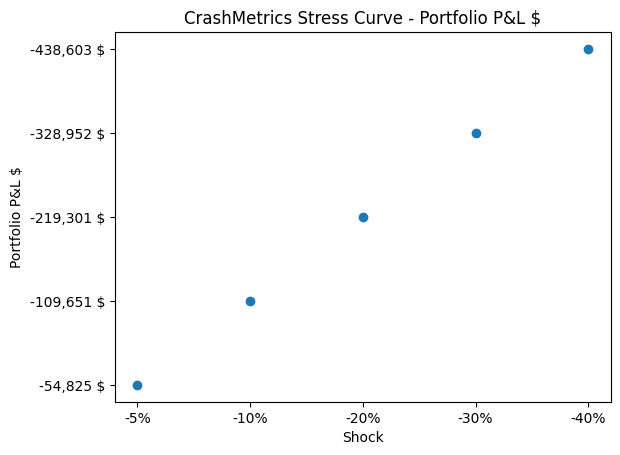

In [97]:
import matplotlib.pyplot as plt

plt.scatter(summary["S&P500 Shock"],summary["Portfolio P&L $"])
plt.xlabel("Shock")
plt.ylabel("Portfolio P&L $")
plt.title("CrashMetrics Stress Curve - Portfolio P&L $")
plt.show()

In [98]:

scenario_10 = stress_results[stress_results["S&P500 Shock"]==-0.1]
scenario_10

pnl_contribution = []
for asset in list(crash_betas["Asset"]):
    pnl = scenario_10[f"{asset} PnL"].iloc[0]
    print(pnl)
    pnl_contribution.append(pnl)

dico = {
    "Asset": list(crash_betas["Asset"]),
    "P&L Contribution $": pnl_contribution

}

contribution = pd.DataFrame(dico)
contribution

-10586.404921972737
-9516.433963829346
-9492.939859625363
-14650.11130805386
-16966.71762776023
-12718.864739804545
-19821.105778777346
-2014.4952629221036
-13859.028702200552
-24.62931126604964


,Asset,P&L Contribution $
0,Nvidia,-10586.404922
1,Apple,-9516.433964
2,Microsoft,-9492.939860
3,JPMorgan,-14650.111308
4,Bank of America,-16966.717628
5,Exxon Mobil,-12718.864740
6,Shell,-19821.105779
7,Gold,-2014.495263
8,Oil,-13859.028702
9,Gas,-24.629311


In [99]:
contribution = contribution.sort_values("P&L Contribution $",ascending=True)
contribution

,Asset,P&L Contribution $
6,Shell,-19821.105779
4,Bank of America,-16966.717628
3,JPMorgan,-14650.111308
8,Oil,-13859.028702
5,Exxon Mobil,-12718.864740
0,Nvidia,-10586.404922
1,Apple,-9516.433964
2,Microsoft,-9492.939860
7,Gold,-2014.495263
9,Gas,-24.629311


In [100]:
contribution["P&L Contribution %"] = (contribution["P&L Contribution $"]/contribution["P&L Contribution $"].sum())*100
contribution

,Asset,P&L Contribution $,P&L Contribution %
6,Shell,-19821.105779,18.076583
4,Bank of America,-16966.717628,15.473419
3,JPMorgan,-14650.111308,13.360705
8,Oil,-13859.028702,12.639249
5,Exxon Mobil,-12718.864740,11.599434
0,Nvidia,-10586.404922,9.654660
1,Apple,-9516.433964,8.678860
2,Microsoft,-9492.939860,8.657434
7,Gold,-2014.495263,1.837193
9,Gas,-24.629311,0.022462


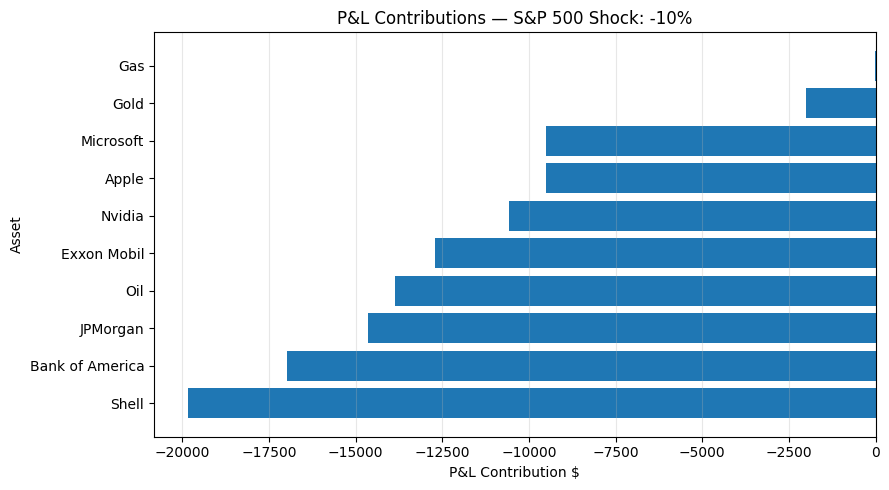

In [101]:
plt.figure(figsize=(9,5))
plt.barh(
    contribution["Asset"],
    contribution["P&L Contribution $"],
)
plt.title("P&L Contributions — S&P 500 Shock: -10%")
plt.xlabel("P&L Contribution $")
plt.ylabel("Asset")
plt.grid(axis="x", alpha=0.3)

plt.tight_layout()
plt.show()


PARTIE HEDGE PROTECTIVE PUT

In [102]:
T = 0.5     # Maturity
r = 0.03    # risk free interest rate
sigma = 0.4 # implied volatility
N = 1000      # number of contracts

S0 = data["S&P 500"].iloc[-1]   # spot price

K = 0.9 * S0    # Strike
print(K)
print(S0)

686.1571105957031
762.3967895507812


In [103]:
# to justify implied vol
crash_days["S&P 500"].nsmallest(5).std() * np.sqrt(252)

np.float64(0.3355753842608687)

In [104]:
# Pricing the Put
from scipy.stats import norm

def put_black_scholes(S,K,r,sigma,T):
    d1 = (np.log(S/K)+(((1/2)*(sigma**2))+r)*T)/(sigma*np.sqrt(T))
    d2 = d1 - sigma*np.sqrt(T)

    P = K*np.exp(-r*T)*norm.cdf(-d2) - norm.cdf(-d1)*S  
    P = P.round(2)

    return P

P = put_black_scholes(S0,K,r,sigma,T)
P

np.float64(44.81)

In [105]:
hedge_cost = N * P
print(hedge_cost)
print(f"Hedge cost as % of portfolio: {hedge_cost / 1_000_000}")



44810.0
Hedge cost as % of portfolio: 0.04481


In [116]:
put_hedge = stress_results[["S&P500 Shock"]]
put_hedge["S&P500 Stressed Price"] = S0 * (1 + put_hedge["S&P500 Shock"])
put_hedge

put_hedge["Put Price"] = put_black_scholes(put_hedge["S&P500 Stressed Price"],K,r,sigma,T)
put_hedge

put_hedge["P&L Put"] = N * (put_hedge["Put Price"] - P)
put_hedge

put_hedge = pd.merge(put_hedge,stress_results[["S&P500 Shock","Portfolio P&L $","Portfolio Return"]],left_on="S&P500 Shock",right_on="S&P500 Shock")
put_hedge

put_hedge["Portfolio P&L hedged"] = put_hedge["Portfolio P&L $"] + put_hedge["P&L Put"]
put_hedge

put_hedge["Portfolio Return hedged"] = put_hedge["Portfolio P&L hedged"] / Initial_capital
put_hedge

C:\Users\antoi\AppData\Local\Temp\ipykernel_19088\104448042.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  put_hedge["S&P500 Stressed Price"] = S0 * (1 + put_hedge["S&P500 Shock"])
C:\Users\antoi\AppData\Local\Temp\ipykernel_19088\104448042.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  put_hedge["Put Price"] = put_black_scholes(put_hedge["S&P500 Stressed Price"],K,r,sigma,T)
C:\Users\antoi\AppData\Local\Temp\ipykernel_19088\104448042.py:8: SettingWithCopyWarning: 
A value is trying to be set on a

,S&P500 Shock,S&P500 Stressed Price,Put Price,P&L Put,Portfolio P&L $,Portfolio Return,Portfolio P&L hedged,Portfolio Return hedged
0,-0.05,724.276950,56.89,12080.0,-54825.365738,-0.054825,-42745.365738,-0.042745
1,-0.10,686.157111,71.59,26780.0,-109650.731476,-0.109651,-82870.731476,-0.082871
2,-0.20,609.917432,110.00,65190.0,-219301.462952,-0.219301,-154111.462952,-0.154111
3,-0.30,533.677753,161.32,116510.0,-328952.194429,-0.328952,-212442.194429,-0.212442
4,-0.40,457.438074,224.48,179670.0,-438602.925905,-0.438603,-258932.925905,-0.258933


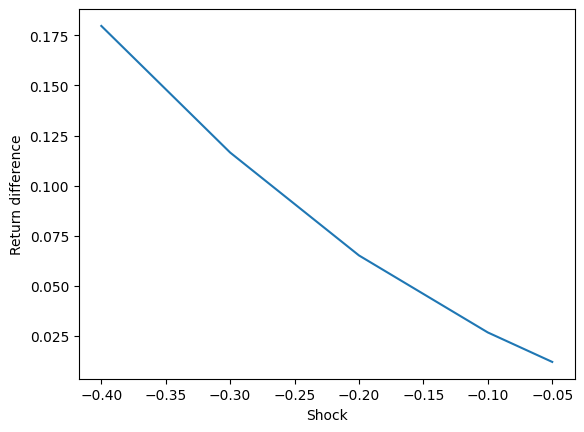

In [120]:
plt.plot(put_hedge["S&P500 Shock"],np.abs(put_hedge["Portfolio Return"]-put_hedge["Portfolio Return hedged"]))
plt.xlabel("Shock")
plt.ylabel("Return difference")
plt.show()

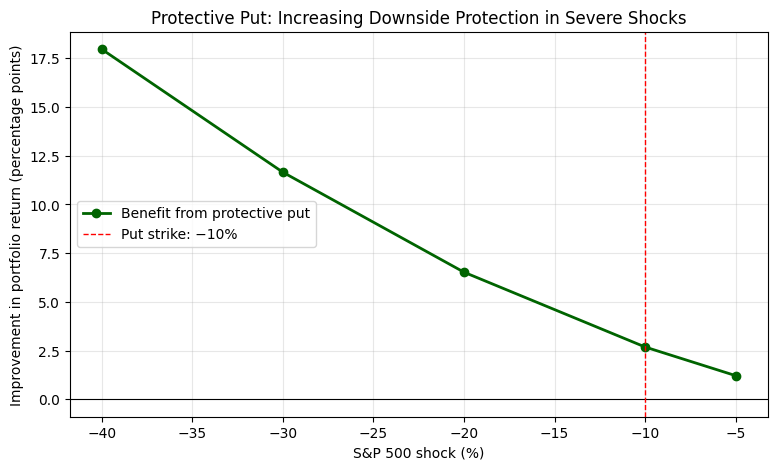

In [121]:
put_hedge["Hedge Benefit"] = (
    put_hedge["Portfolio Return hedged"]
    - put_hedge["Portfolio Return"]
)

plt.figure(figsize=(9, 5))

plt.plot(
    put_hedge["S&P500 Shock"] * 100,
    put_hedge["Hedge Benefit"] * 100,
    marker="o",
    linewidth=2,
    color="darkgreen",
    label="Benefit from protective put"
)

plt.axhline(0, color="black", linewidth=0.8)
plt.axvline(-10, color="red", linestyle="--", linewidth=1,
            label="Put strike: −10%")

plt.xlabel("S&P 500 shock (%)")
plt.ylabel("Improvement in portfolio return (percentage points)")
plt.title("Protective Put: Increasing Downside Protection in Severe Shocks")
plt.grid(alpha=0.3)
plt.legend()
plt.show()

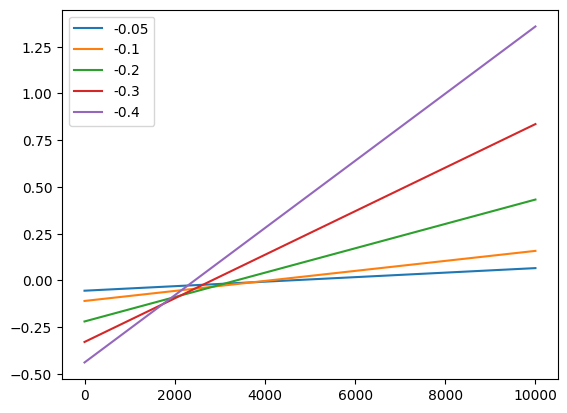

In [129]:
X = np.linspace(0,10_000,1000)
for _,row in put_hedge.iterrows():
    shock = row["S&P500 Shock"]
    Y = []
    for x in X:
        PnL_put = x * (row["Put Price"] - P)
        portfolio_PnL_hedged = row["Portfolio P&L $"] + PnL_put
        portfolio_return_hedged = portfolio_PnL_hedged / Initial_capital
        Y.append(portfolio_return_hedged)

    plt.plot(X,Y,label=shock)
    plt.legend()
